<a href="https://colab.research.google.com/github/dherreraal/data_structures/blob/main/Clase_04/04_ED_Stacks_Queues.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estructuras de Datos: Pilas y Colas Simples
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez
#### **Curso:** Estructuras de Datos
---


## Índice de Contenido
1. Introducción a Estructuras Restringidas
2. Principios de Ordenamiento: LIFO vs FIFO
3. Pilas (Stacks)
   - 3.1. Estado Inicial: Pila Vacía
   - 3.2. Operación Push (Insertar)
   - 3.3. Operación Pop (Eliminar)
4. Aplicación Práctica (Pilas): Invertir una Cadena
5. Colas (Queues)
   - 5.1. Estado Inicial: Cola Vacía
   - 5.2. Operación Enqueue (Insertar/Encolar)
   - 5.3. Operación Dequeue (Eliminar/Desencolar)
6. Ejercicio Práctico: Simple Queue
7. Bibliografía
---


## 1. Introducción a Estructuras Restringidas

Ya estudiadas las **Listas**, las cuales nos permitían insertar, eliminar o buscar elementos en *cualquier* posición (principio, medio o final). Nos damos cuenta de algo, a veces tanta libertad puede causar problemas de diseño, rendimiento o control en ciertos algoritmos.

Por ello, la Ciencias de la Computación introdujo estructuras de datos **restringidas**: colecciones donde solo se puede interactuar con los elementos siguiendo reglas muy estrictas de entrada y salida. Las dos más fundamentales son la **Pila (Stack)** y la **Cola (Queue)**.


## 2. Principios de Ordenamiento: LIFO vs FIFO

Antes de programar nuestras estructuras, es fundamental entender las dos reglas universales (principios) que dictan en qué orden entran y salen los datos en las colecciones restringidas.

### El Principio LIFO (Last-In, First-Out)
Significa **"Último en Entrar, Primero en Salir"**.
Este principio define el comportamiento de las **Pilas (Stacks)**. Visualícelo como un tubo cerrado por abajo: solo puede meter cosas por arriba, y solo puede sacar lo que está inmediatamente arriba. El último dato que usted metió, obliga a los demás a quedarse atrapados hasta que ese último dato sea retirado.

![LIFO Principle](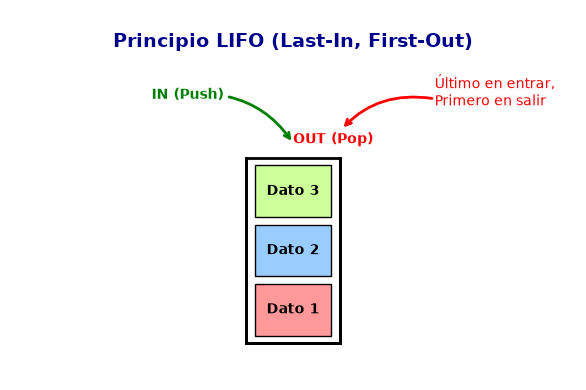 "LIFO")

### El Principio FIFO (First-In, First-Out)
Significa **"Primero en Entrar, Primero en Salir"**.
Este principio define el comportamiento de las **Colas (Queues)**. Funciona como un tubo abierto por ambos lados o como una fila del banco: la primera persona que llegó a la fila, es la primera persona que será atendida y saldrá.

![FIFO Principle](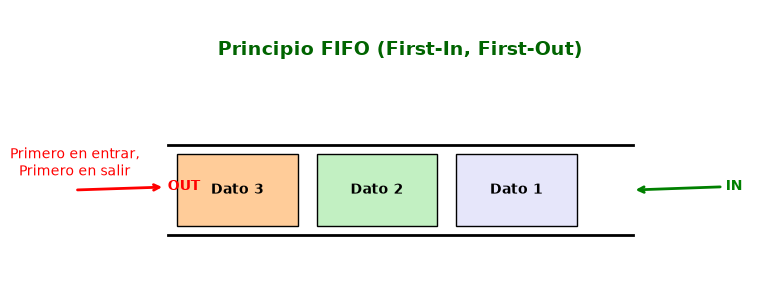 "FIFO")


## 3. Pilas (Stacks)

Una **Pila (Stack)** opera bajo el principio **LIFO** (Last-In, First-Out / *Último en Entrar, Primero en Salir*). Imagínese una pila de platos en la cafetería: solo puede agregar un plato nuevo encima del todo, y si necesita tomar un plato, solo puede sacar el que está encima del todo.

### 3.1. Estado Inicial: Pila Vacía
Para implementar una Pila usando un arreglo, solo necesitamos guardar nuestros datos y usar una variable de control llamada `top` (cima) que apunte al índice del elemento superior.

![Stack Empty](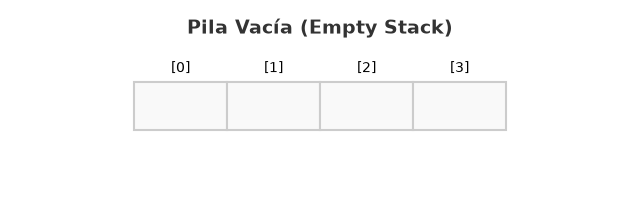 "Stack Empty")

Cuando la pila está vacía, iniciamos `top` en `-1` porque el índice `0` significaría que ya hay un elemento.


In [1]:
%%writefile StackArray.java
public class StackArray {
    protected int[] data;
    protected int top;

    public StackArray(int capacity) {
        data = new int[capacity];
        top = -1; // Inicialmente vacío
    }

    public boolean empty() {
        return top == -1;
    }

    public void printStack() {
        System.out.print("Stack [ ");
        for (int i = 0; i <= top; i++) System.out.print(data[i] + " ");
        System.out.println("] <- top");
    }
    // Métodos vacíos por ahora
    public void push(int value) {}
    public int pop() { return -1; }
}


Writing StackArray.java


### 3.2. Operación Push (Insertar)
Cuando hacemos `Push(10)`, primero movemos la flecha `top` hacia arriba (incrementa a `0`) y luego colocamos el dato allí.

![Stack Push 10](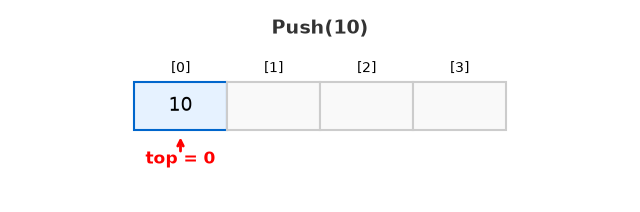 "Push 10")

Si volvemos a hacer `Push(20)`, el `top` sube a `1` y allí queda el `20`.

![Stack Push 20](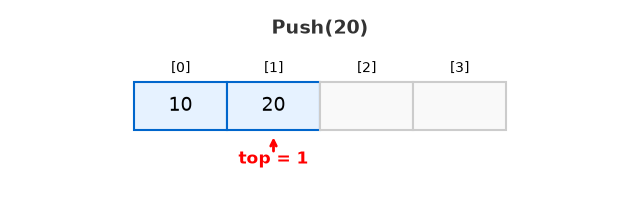 "Push 20")

A continuación, implementamos la lógica de `push`.

In [2]:
%%writefile StackArray.java
public class StackArray {
    protected int[] data;
    protected int top;

    public StackArray(int capacity) {
        data = new int[capacity];
        top = -1;
    }

    public boolean empty() { return top == -1; }

    // --- NUEVO MÉTODO PUSH ---
    public void push(int value) {
        if (top == data.length - 1) {
            System.out.println("Error: Stack Overflow (Pila llena)");
            return;
        }
        top++;              // Subimos el puntero
        data[top] = value;  // Colocamos el valor
    }

    public void printStack() {
        System.out.print("Stack [ ");
        for (int i = 0; i <= top; i++) System.out.print(data[i] + " ");
        System.out.println("] <- top");
    }

    public int pop() { return -1; }
}


Overwriting StackArray.java


In [3]:
%%writefile PruebaPush.java
public class PruebaPush {
    public static void main(String[] args) {
        StackArray pila = new StackArray(4);
        pila.push(10);
        pila.printStack();
        pila.push(20);
        pila.printStack();
    }
}


Writing PruebaPush.java


In [4]:
!javac StackArray.java PruebaPush.java
!java PruebaPush


[0.017s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.017s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Stack [ 10 ] <- top
Stack [ 10 20 ] <- top


### 3.3. Operación Pop (Eliminar)
Para retirar un elemento, siempre retiramos el que está en `top`. Al hacer `Pop()`, primero guardamos el `20`, y simplemente bajamos el `top` a `0`. Note que no nos interesa "borrar" el `20` de la memoria, al bajar el `top`, ese `20` queda invisible e inaccesible para nuestra estructura.

![Stack Pop](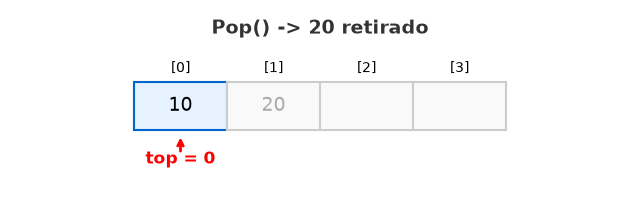 "Pop")

Veamos la implementación final del Stack:

In [5]:
%%writefile StackArray.java
public class StackArray {
    protected int[] data;
    protected int top;

    public StackArray(int capacity) {
        data = new int[capacity];
        top = -1;
    }

    public boolean empty() { return top == -1; }
    public void push(int value) {
        if (top == data.length - 1) return;
        data[++top] = value;
    }

    // --- NUEVO MÉTODO POP ---
    public int pop() {
        if (empty()) {
            System.out.println("Error: Stack Underflow (Pila vacía)");
            return -1;
        }
        int valor = data[top]; // Guardamos el valor superior
        top--;                 // Bajamos el puntero (el valor queda 'muerto')
        return valor;          // Retornamos el valor
    }

    public void printStack() {
        System.out.print("Stack final [ ");
        for (int i = 0; i <= top; i++) System.out.print(data[i] + " ");
        System.out.println("] <- top");
    }
}


Overwriting StackArray.java


In [6]:
%%writefile PruebaPop.java
public class PruebaPop {
    public static void main(String[] args) {
        StackArray pila = new StackArray(4);
        pila.push(10);
        pila.push(20);
        System.out.println("Retirando el elemento: " + pila.pop());
        pila.printStack();
    }
}


Writing PruebaPop.java


In [7]:
!javac StackArray.java PruebaPop.java
!java PruebaPop


[0.002s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Retirando el elemento: 20
Stack final [ 10 ] <- top


---
## 4. Aplicación Práctica: Invertir una Palabra con un Stack

Según el **Capítulo 2.5** del libro, una de las aplicaciones más clásicas y útiles del principio LIFO de una Pila es invertir el orden de un conjunto de datos.

Si tomamos la palabra `"HOLA"` e insertamos (Push) sus letras una por una en una Pila, entrarán en este orden: `H`, `O`, `L`, `A`.
Al estar la `A` en la cima (top), si comenzamos a sacarlas (Pop), saldrán en orden inverso: `A`, `L`, `O`, `H`.

Veámoslo en código usando la clase `StackArray` que acabamos de crear (ligeramente adaptada para caracteres):


In [8]:
%%writefile InvertirPalabra.java
class StackChar {
    char[] data;
    int top;

    public StackChar(int capacity) {
        data = new char[capacity];
        top = -1;
    }

    public boolean empty() { return top == -1; }
    public void push(char c) { data[++top] = c; }
    public char pop() { return data[top--]; }
}

public class InvertirPalabra {
    public static void main(String[] args) {
        String original = "ESTRUCTURAS";
        System.out.println("Palabra Original: " + original);

        // 1. Crear una pila del tamaño de la palabra
        StackChar pila = new StackChar(original.length());

        // 2. Push: Meter cada letra a la pila
        for (int i = 0; i < original.length(); i++) {
            pila.push(original.charAt(i));
        }

        // 3. Pop: Sacar las letras (saldrán al revés)
        System.out.print("Palabra Invertida: ");
        while (!pila.empty()) {
            System.out.print(pila.pop());
        }
        System.out.println();
    }
}


Writing InvertirPalabra.java


In [9]:
!javac InvertirPalabra.java
!java InvertirPalabra


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Palabra Original: ESTRUCTURAS
Palabra Invertida: SARUTCURTSE


---
## 5. Colas (Queues)

Una **Cola (Queue)** opera bajo el principio **FIFO** (First-In, First-Out / *Primero en Entrar, Primero en Salir*). Es igual a una fila en el supermercado: usted llega y se forma por detrás (`rear`), y la cajera atiende a la persona que está enfrente (`front`).

### 5.1. Estado Inicial: Cola Vacía
A diferencia del Stack que requería 1 puntero (`top`), la Cola necesita 2 punteros: `front` (para saber a quién atender) y `rear` (para saber dónde meter a la siguiente persona).

![Queue Empty](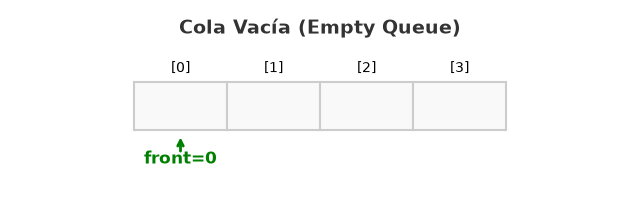 "Queue Empty")

### 5.2. Operación Enqueue (Insertar/Encolar)
Cuando llega un nuevo dato, digamos `Enqueue(5)`, movemos el `rear` y allí colocamos el dato.

![Queue Enqueue 5](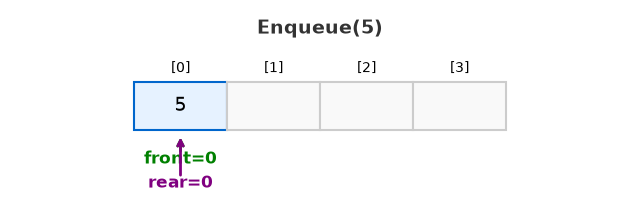 "Enqueue 5")

Si hacemos `Enqueue(8)`, el `rear` vuelve a avanzar, pero el `front` se queda quieto.

![Queue Enqueue 8](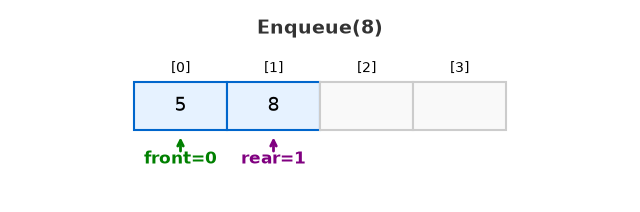 "Enqueue 8")


In [10]:
%%writefile PruebaQueueTeorico.java
// Aquí verá cómo la lógica de la cola avanza el 'rear'.
// El código detallado formará parte de su Ejercicio Práctico más abajo.
public class PruebaQueueTeorico {
    public static void main(String[] args) {
        System.out.println("Note cómo 'rear' avanza al encolar, mientras 'front' espera paciente.");
    }
}


Writing PruebaQueueTeorico.java


In [11]:
!javac PruebaQueueTeorico.java
!java PruebaQueueTeorico


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Note cómo 'rear' avanza al encolar, mientras 'front' espera paciente.


### 5.3. Operación Dequeue (Eliminar/Desencolar)
Cuando despachamos un elemento, lo hacemos desde el `front`. Hacemos `Dequeue()`, retiramos el `5` y avanzamos el puntero `front`.

![Queue Dequeue](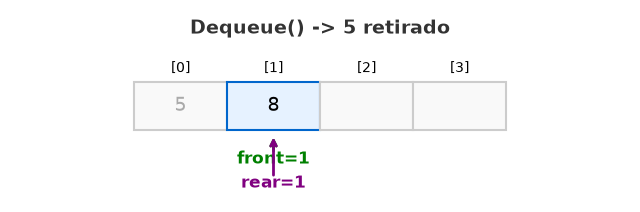 "Dequeue")

> [!WARNING]
> **El problema de la Cola Simple (Deslizamiento):**
> Observe bien la figura de arriba. Después de varios `Enqueue` y `Dequeue`, ambos punteros avanzarán irremediablemente hacia la derecha. Eventualmente `rear` chocará con el final del arreglo y dirá que la cola "está llena", a pesar de que hay espacios vacíos a la izquierda (donde estaba el `5`). La solución a esto es la *Cola Circular*, tema de la Clase 7.


---
## 6. Ejercicio Práctico: Simple Queue

Es su turno de implementar la Cola Simple vista en los diagramas. Siga cuidadosamente las instrucciones en los comentarios para llenar los métodos `enqueue` y `dequeue`.


In [12]:
%%writefile SimpleQueue.java
public class SimpleQueue {
    private int[] data;
    private int front;
    private int rear;

    public SimpleQueue(int capacity) {
        data = new int[capacity];
        front = 0;
        rear = -1;
    }

    public boolean empty() {
        return front > rear; // Si front sobrepasa a rear, la cola está vacía
    }

    /**
     * Agrega un valor a la cola (por detrás)
     */
    public void enqueue(int value) {
        if (rear == data.length - 1) {
            System.out.println("Error: La cola está llena (Overflow)");
            return;
        }

        // SU CÓDIGO AQUÍ:
        // 1. Incremente el puntero 'rear'.
        // 2. Asigne el 'value' en la posición 'rear' del arreglo 'data'.

    }

    /**
     * Saca y retorna un valor de la cola (por el frente)
     */
    public int dequeue() {
        if (empty()) {
            System.out.println("Error: La cola está vacía (Underflow)");
            return -1;
        }

        // SU CÓDIGO AQUÍ:
        // 1. Guarde el valor que está en la posición 'front'.
        // 2. Incremente el puntero 'front' para avanzar en la fila.
        // 3. Retorne el valor guardado.
        return 0; // Cambie esto
    }

    public void printQueue() {
        System.out.print("Queue: front[");
        for (int i = front; i <= rear; i++) {
            System.out.print(" " + data[i]);
        }
        System.out.println(" ]rear");
    }
}


Writing SimpleQueue.java


In [13]:
%%writefile PruebaSimpleQueue.java
public class PruebaSimpleQueue {
    public static void main(String[] args) {
        SimpleQueue cola = new SimpleQueue(5);

        cola.enqueue(5);
        cola.enqueue(8);
        cola.enqueue(12);

        // Debería imprimir: Queue: front[ 5 8 12 ]rear
        cola.printQueue();

        // Debería sacar el 5 y luego imprimir: Queue: front[ 8 12 ]rear
        /* Descomente estas líneas para probar
        System.out.println("Atendiendo a: " + cola.dequeue());
        cola.printQueue();
        */
    }
}


Writing PruebaSimpleQueue.java


In [14]:
!javac SimpleQueue.java PruebaSimpleQueue.java
!java PruebaSimpleQueue


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Queue: front[ ]rear


---
## 7. Bibliografía
*   Streib, J. T., & Soma, T. (2017). *Guide to Data Structures: A Concise Introduction Using Java*. Springer.
    * Capítulo 2: Stacks Using Arrays
    * Capítulo 3: Queues Using Arrays
*   Rhodes, N. *Basic Data Structures: Stacks and Queues* (Diapositivas).
